# Install Nebula

To run nebula scirbt you need the follwing libraries:

```R
    library(glue)
    library(dplyr)
    library(getopt)
    library(Matrix)
    library(qs)
    library(Seurat)
    library(nebula)
    library(future)
```

```R
install.packages("getopt")

if (!require("devtools")) install.packages("devtools")
devtools::install_github("lhe17/nebula")

if (!require("BiocManager")) install.packages("BiocManager")
BiocManager::install("biomaRt")

```

R scritp from [link](https://github.com/bdferris642/sc-online/tree/main/scripts)

# Hyperparameters

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

DATASET_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "baseline_nebula"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [ ]:
def add_metadata_to_qs(base_qs_path, new_metadata_df_path, barcode_col="barcode"):
    """
    Updates metadata in existing .qs file
    """
    
    ro.r(f'''
        library(qs)
        
        # Read object
        sc_obj <- qread("{base_qs_path}")
        
        # Merge new metadata
        new_meta <- read.csv("{new_metadata_df_path}")
        sc_obj@meta.data <- merge(
            sc_obj@meta.data,
            new_meta,
            by.x = "row.names",
            by.y = "{barcode_col}",
            all.x = TRUE            # Keep ALL cells from original (left join)
        )
        rownames(sc_obj@meta.data) <- sc_obj@meta.data$Row.names  # Restore barcodes as rownames
        sc_obj@meta.data$Row.names <- NULL                         # Remove the extra column
        
        # Resave (only once!)
        qsave(sc_obj, "{base_qs_path}", nthreads = 4)
    ''')

In [6]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, f"{dataset}.qs")
    cov_df_csv_path = os.path.join(results_folder, "covariates_df.csv")
    os.makedirs(results_folder, exist_ok=True)

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)


    ##################

    # Update obs of .qs obj
    # add_metadata_to_qs(
    #     base_qs_path=dataset_path_qs,
    #     new_metadata_df=pd.read_csv(cov_df_csv_path),
    #     barcode_col="barcode",
    # )

    #break


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######


######
 Processing dataset: depleted_0.01_dorsal_matrix 
######


######
 Processing dataset: depleted_0.05_dorsal_matrix 
######


######
 Processing dataset: depleted_0.10_dorsal_matrix 
######


######
 Processing dataset: depleted_0.20_dorsal_matrix 
######


######
 Processing dataset: depleted_0.30_dorsal_matrix 
######


######
 Processing dataset: depleted_0.40_dorsal_matrix 
######


######
 Processing dataset: depleted_0.50_dorsal_matrix 
######



# DEG

In [4]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    dataset="depleted_0.05_dorsal_matrix"

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 20, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 7, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    break

    


######
 Processing dataset: depleted_0.05_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.05_dorsal_matrix/baseline_nebula/depleted_0.05_dorsal_matrix-baseline_nebula_results.csv
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.05_dorsal_matrix/depleted_0.05_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 20 --n-cores 7 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic
STDOUT:
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.05_dorsal_matrix/depleted_0.05_dorsal_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: depleted_0.05_dorsal_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset

# Plot Results

In [12]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



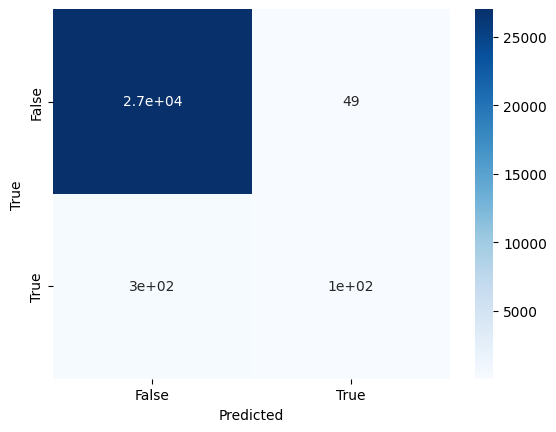

Precision: 0.680
Recall:    0.260
F1 Score:  0.376
Accuracy:  0.987
Clipping 19 genes with -log10(p) > 10


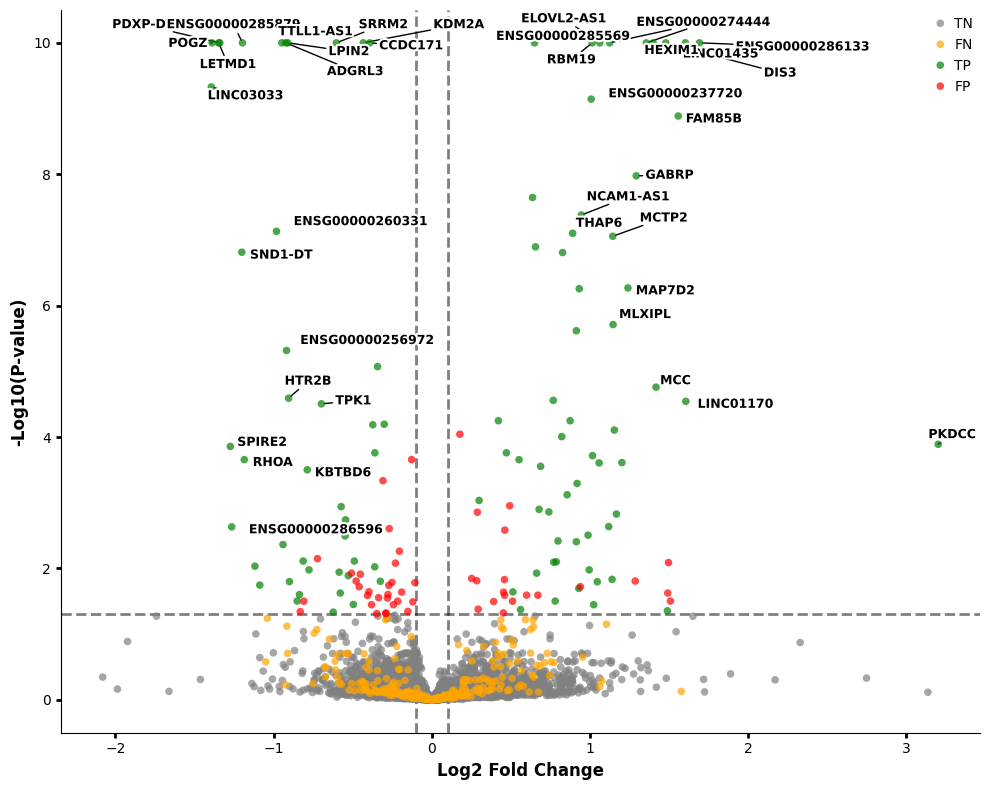

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.136511,0.001079,0.134554,False,False,0.871103,TN,-0.118915
1,A1BG-AS1,-0.039304,0.452345,0.884819,False,False,0.053146,TN,-0.002089
2,A1CF,-0.263262,0.013398,0.470287,False,False,0.327637,TN,-0.086254
3,A2M,0.235039,0.160924,0.777411,False,False,0.109350,TN,0.025701
4,A2M-AS1,0.019844,0.756238,0.952591,False,False,0.021093,TN,0.000419
...,...,...,...,...,...,...,...,...,...
27476,ZZEF1,-0.038951,0.101827,0.731021,False,False,0.136070,TN,-0.005300
27477,ZZZ3,0.023772,0.668428,0.936730,False,False,0.028385,TN,0.000675
27478,ENSG00000205653,0.391694,0.566351,0.913812,False,False,0.039143,TN,0.015332
27479,ENSG00000223438,0.017123,0.980015,0.997634,False,False,0.001029,TN,0.000018


In [13]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break